# 2. Process The Videos Using Mediapipe

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pose_processor import MediaPipePoseProcessor
import matplotlib.patches as patches

# Set up notebook to display plots inline
%matplotlib inline

print("✓ Imports successful!")

✓ Imports successful!


## Find the videos

In [4]:
# Path to the folder containing your synchronized videos
# This should contain files like camera_0_synchronized.mp4, camera_1_synchronized.mp4, etc.
INPUT_VIDEO_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/synchronized_videos"

# Path where you want to save the outputs
# This will create subfolders for labeled videos and 2D keypoint data
OUTPUT_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output"

print(f"Input directory: {INPUT_VIDEO_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Verify the input directory exists and contains videos
input_path = Path(INPUT_VIDEO_DIR)
if input_path.exists():
    video_files = list(input_path.glob("*.mp4")) + list(input_path.glob("*.avi"))
    print(f"✓ Found {len(video_files)} video files")
    for video in video_files:
        print(f"  - {video.name}")
else:
    print("✗ ERROR: Input directory does not exist!")


Input directory: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/synchronized_videos
Output directory: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output
✓ Found 3 video files
  - camera_2_synchronized.mp4
  - camera_0_synchronized.mp4
  - camera_1_synchronized.mp4


### Initialize the MediaPipe Pose Processor

In [9]:
processor = MediaPipePoseProcessor(
    input_dir=INPUT_VIDEO_DIR,
    output_dir=OUTPUT_DIR,
    
    # Confidence thresholds (0.0 to 1.0)
    # Higher = more strict, fewer false positives but might miss some frames
    # Lower = more detections but might have more false positives
    min_detection_confidence=0.5,  # Threshold for initial detection
    min_tracking_confidence=0.5,   # Threshold for tracking across frames
    
    # Model complexity (0, 1, or 2)
    # 0 = fastest, least accurate
    # 1 = balanced
    # 2 = slowest, most accurate
    model_complexity=2,
    
    # Whether to apply temporal smoothing (reduces jitter)
    smooth_landmarks=True
)

print("MediaPipe Pose Processor initialized!")
print(f"  - Model complexity: 2 (most accurate)")
print(f"  - Detection confidence: 0.5")
print(f"  - Tracking confidence: 0.5")


2026-02-09 13:43:33,835 - INFO - MediaPipe Pose Processor initialized
I0000 00:00:1770644613.834912 8961285 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M3


2026-02-09 13:43:33,836 - INFO - Input directory: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/synchronized_videos
2026-02-09 13:43:33,836 - INFO - Output directory: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output
2026-02-09 13:43:33,836 - INFO - Model complexity: 2


MediaPipe Pose Processor initialized!
  - Model complexity: 2 (most accurate)
  - Detection confidence: 0.5
  - Tracking confidence: 0.5


W0000 00:00:1770644613.907368 8986137 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770644613.942271 8986141 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Process ALL videos at once

### To do: speed this up and make it parallel

In [10]:
# This will automatically process all videos in your input directory
# and generate labeled videos + 2D keypoint data for each

print("\n" + "="*70)
print("Starting 2D pose estimation on all videos...")
print("="*70)

# This will take a few minutes depending on video length and number of cameras
# You'll see a progress bar for each video
metrics_all = processor.process_all_videos(save_labeled_videos=True)

print("\nAll videos processed successfully!")

2026-02-09 13:43:37,792 - INFO - Found 3 video files
2026-02-09 13:43:37,793 - INFO - Processing video: camera_0_synchronized
2026-02-09 13:43:37,814 - INFO - Video properties: 1280x720 @ 30fps, 1802 frames



Starting 2D pose estimation on all videos...


Processing camera_0_synchronized: 100%|██████████| 1802/1802 [01:49<00:00, 16.38it/s]
2026-02-09 13:45:27,901 - INFO - Saved keypoints data to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d
2026-02-09 13:45:27,901 - INFO - Completed processing camera_0_synchronized
2026-02-09 13:45:27,901 - INFO - Detection rate: 100.00%
2026-02-09 13:45:27,902 - INFO - Processing video: camera_1_synchronized
2026-02-09 13:45:27,904 - INFO - Video properties: 1280x720 @ 30fps, 1802 frames
Processing camera_1_synchronized: 100%|██████████| 1802/1802 [01:52<00:00, 16.06it/s]
2026-02-09 13:47:20,224 - INFO - Saved keypoints data to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d
2026-02-09 13:47:20,224 - INFO - Completed processing camera_1_synchronized
2026-02-09 13:47:20,225 - INFO - Detection rate: 100.00%
2026-02-09 13:47:20,225 - INFO - Processing video: camera_2_synchronized
2026-02-09 13:47:20,228 - INFO - Video properti


All videos processed successfully!


## View the results/metrics

In [11]:
print("\n" + "="*70)
print("2D POSE ESTIMATION RESULTS")
print("="*70)

for camera_name, metrics in metrics_all.items():
    print(f"\n{camera_name}:")
    print(f"  Total frames:          {metrics.total_frames}")
    print(f"  Frames with detection: {metrics.frames_with_detection}")
    print(f"  Detection rate:        {metrics.detection_rate:.2%}")
    print(f"  Average confidence:    {metrics.avg_confidence:.4f}")
    print(f"  Confidence range:      {metrics.min_confidence:.4f} to {metrics.max_confidence:.4f}")
    print(f"  Keypoints per frame:   {metrics.keypoints_per_frame}")



2D POSE ESTIMATION RESULTS

camera_0_synchronized:
  Total frames:          1802
  Frames with detection: 1802
  Detection rate:        100.00%
  Average confidence:    0.6947
  Confidence range:      0.0007 to 1.0000
  Keypoints per frame:   33

camera_1_synchronized:
  Total frames:          1802
  Frames with detection: 1802
  Detection rate:        100.00%
  Average confidence:    0.7522
  Confidence range:      0.0014 to 1.0000
  Keypoints per frame:   33

camera_2_synchronized:
  Total frames:          1802
  Frames with detection: 1802
  Detection rate:        100.00%
  Average confidence:    0.7616
  Confidence range:      0.0015 to 1.0000
  Keypoints per frame:   33


## Load and examine the 2D keypoint data

The keypoints are saved as .npy files in the data_2d folder


In [12]:
# Example: Load keypoints from the first camera
data_2d_dir = Path(OUTPUT_DIR) / "data_2d"
keypoint_files = list(data_2d_dir.glob("*_keypoints.npy"))

if keypoint_files:
    # Load the first camera's keypoints
    first_camera_keypoints = np.load(keypoint_files[0])
    
    print(f"\n✓ Loaded keypoints from: {keypoint_files[0].name}")
    print(f"  Shape: {first_camera_keypoints.shape}")
    print(f"  Format: (n_frames, n_keypoints, 3)")
    print(f"  Where last dimension is [x_pixel, y_pixel, confidence]")
    
    # Show example data from first frame
    print(f"\n  Example - Frame 0, Keypoint 0 (nose):")
    print(f"    X position: {first_camera_keypoints[0, 0, 0]:.2f} pixels")
    print(f"    Y position: {first_camera_keypoints[0, 0, 1]:.2f} pixels")
    print(f"    Confidence: {first_camera_keypoints[0, 0, 2]:.4f}")



✓ Loaded keypoints from: camera_2_synchronized_keypoints.npy
  Shape: (1802, 33, 3)
  Format: (n_frames, n_keypoints, 3)
  Where last dimension is [x_pixel, y_pixel, confidence]

  Example - Frame 0, Keypoint 0 (nose):
    X position: 668.06 pixels
    Y position: 172.99 pixels
    Confidence: 0.9995


## Smooth the points

2026-02-09 13:49:17,090 - INFO - MediaPipe Pose Processor initialized
I0000 00:00:1770644957.089873 8961285 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M3
2026-02-09 13:49:17,090 - INFO - Input directory: .
2026-02-09 13:49:17,091 - INFO - Output directory: .
2026-02-09 13:49:17,091 - INFO - Model complexity: 2
2026-02-09 13:49:17,112 - INFO - Applying Butterworth filter (cutoff=2.0Hz, order=4)
2026-02-09 13:49:17,123 - INFO - Filtering complete:
2026-02-09 13:49:17,124 - INFO -   - Total signals processed: 66
2026-02-09 13:49:17,124 - INFO -   - Signals skipped: 0
2026-02-09 13:49:17,124 - INFO -   - NaN values interpolated: 0
2026-02-09 13:49:17,127 - INFO - Applying Butterworth filter (cutoff=2.0Hz, order=4)
2026-02-09 13:49:17,135 - INFO - Filtering complete:
2026-02-09 13:49:17,135 - INFO -   - Total signals processed: 66
2026-02-09 13:49:17,135 - INFO -   - Signals skipped: 0
2026-02-09 13:49:17,136 - INFO -   - NaN values interpolated: 0
2026-02-09 13:

Loading and smoothing keypoint data

camera_0_synchronized: (1802, 33, 3)
  Processing 33 keypoints across 1802 frames...
  ✓ Smoothed ALL keypoints and saved to: camera_0_synchronized_keypoints.npy

camera_1_synchronized: (1802, 33, 3)
  Processing 33 keypoints across 1802 frames...
  ✓ Smoothed ALL keypoints and saved to: camera_1_synchronized_keypoints.npy

camera_2_synchronized: (1802, 33, 3)
  Processing 33 keypoints across 1802 frames...
  ✓ Smoothed ALL keypoints and saved to: camera_2_synchronized_keypoints.npy

✓ Processed 3 cameras

Creating BEFORE/AFTER visualization


W0000 00:00:1770644957.171337 8991683 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770644957.207415 8991688 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



✓ Saved visualization: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/left_wrist_before_after.png


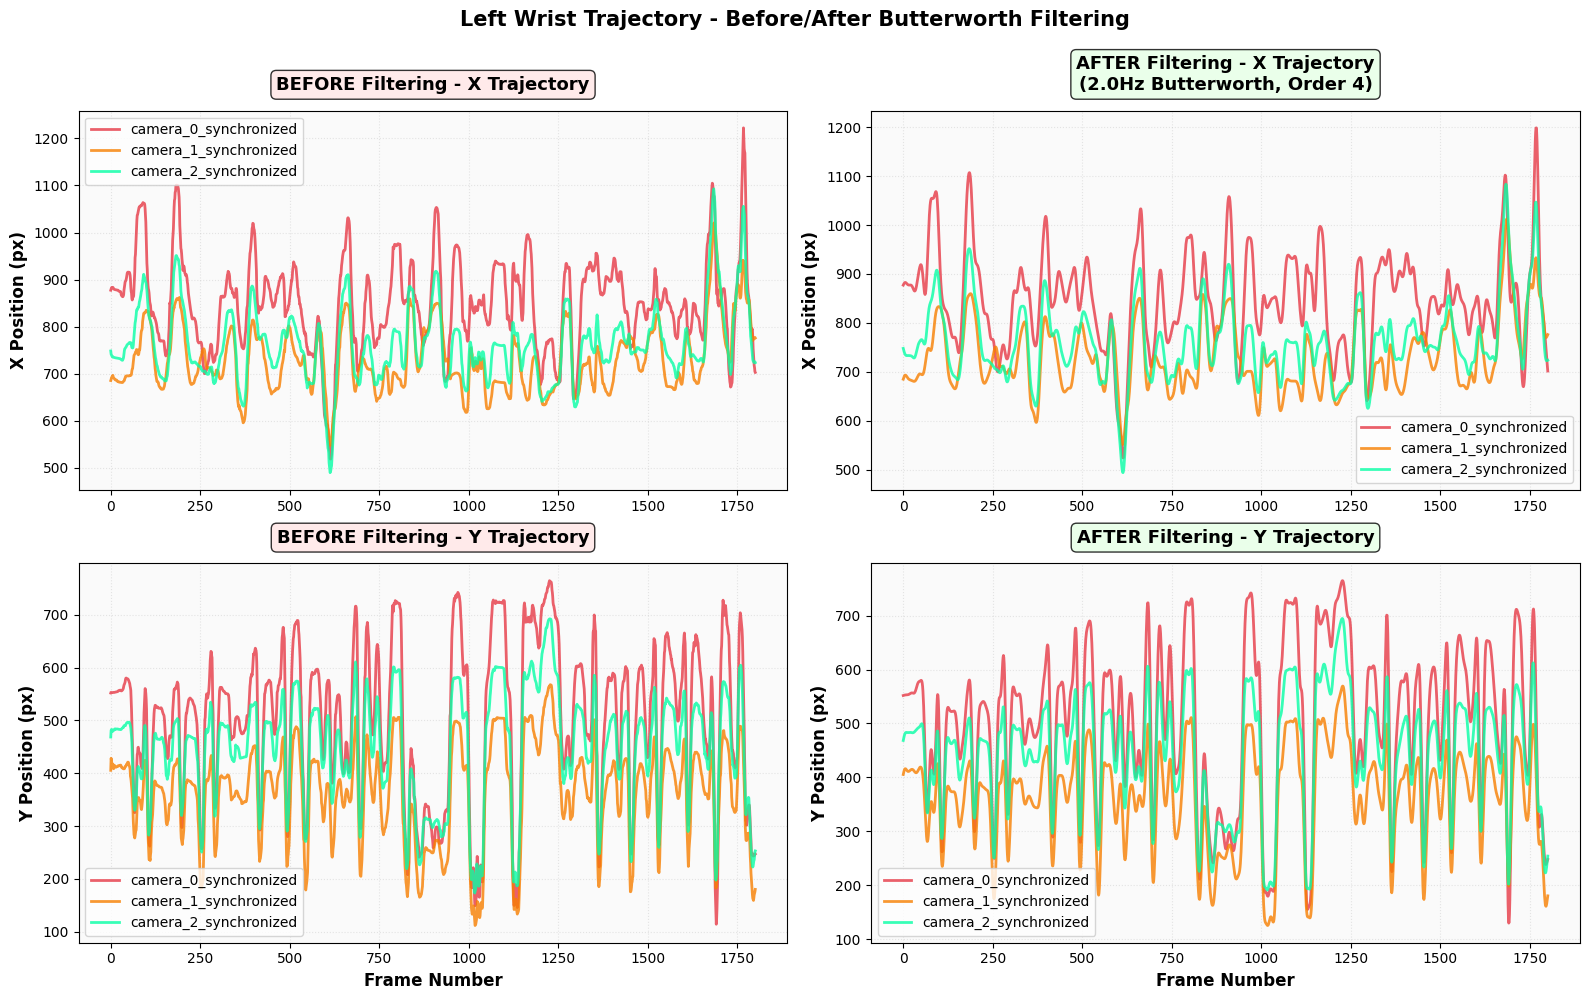


Left Wrist Jitter Reduction Statistics
camera_0_synchronized:
  BEFORE: 6.84 px/frame
  AFTER:  6.44 px/frame
  Reduction: 5.8%
camera_1_synchronized:
  BEFORE: 4.32 px/frame
  AFTER:  4.07 px/frame
  Reduction: 5.9%
camera_2_synchronized:
  BEFORE: 4.94 px/frame
  AFTER:  4.71 px/frame
  Reduction: 4.8%


AttributeError: 'PosixPath' object has no attribute 'shape'

In [13]:
# ============================================================================
# Load all keypoints, apply Butterworth smoothing, save, and visualize
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pose_processor import MediaPipePoseProcessor

# Configuration
data_2d_dir = Path(OUTPUT_DIR) / "data_2d"
LEFT_WRIST_IDX = 15  # MediaPipe landmark index
CUTOFF_FREQ = 2.0    # Hz
FILTER_ORDER = 4
SAMPLING_FREQ = 30.0 # Hz

# Bold colors for plotting
COLORS = ['#E63946', '#F77F00', '#06FFA5', '#118AB2', '#073B4C']

# ============================================================================
# Load and smooth all cameras
# ============================================================================
print("="*70)
print("Loading and smoothing keypoint data")
print("="*70)

keypoint_files = sorted(data_2d_dir.glob("*_keypoints.npy"))
raw_data = {}
smoothed_data = {}
processor = MediaPipePoseProcessor(input_dir=".", output_dir=".")

for kp_file in keypoint_files:
    cam_name = kp_file.stem.replace("_keypoints", "")
    keypoints = np.load(kp_file)
    
    print(f"\n{cam_name}: {keypoints.shape}")
    print(f"  Processing {keypoints.shape[1]} keypoints across {keypoints.shape[0]} frames...")
    
    # Store raw data BEFORE smoothing
    raw_data[cam_name] = keypoints.copy()
    
    # Apply Butterworth smoothing to ALL keypoints (X and Y only, confidence preserved)
    smoothed = processor.smooth_keypoints_butterworth(
        keypoints,
        cutoff_freq=CUTOFF_FREQ,
        sampling_freq=SAMPLING_FREQ,
        order=FILTER_ORDER
    )
    smoothed_data[cam_name] = smoothed
    
    # Overwrite original file with smoothed data
    np.save(kp_file, smoothed)
    print(f"  ✓ Smoothed ALL keypoints and saved to: {kp_file.name}")

print(f"\n✓ Processed {len(keypoint_files)} cameras")

# ============================================================================
# Plot BEFORE and AFTER for left wrist trajectories
# ============================================================================
print("\n" + "="*70)
print("Creating BEFORE/AFTER visualization")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Left column = BEFORE (raw), Right column = AFTER (smoothed)
ax_x_before, ax_x_after = axes[0, 0], axes[0, 1]
ax_y_before, ax_y_after = axes[1, 0], axes[1, 1]

for idx, (cam_name, raw_kp) in enumerate(raw_data.items()):
    smoothed_kp = smoothed_data[cam_name]
    
    # Extract left wrist
    raw_x = raw_kp[:, LEFT_WRIST_IDX, 0]
    raw_y = raw_kp[:, LEFT_WRIST_IDX, 1]
    smooth_x = smoothed_kp[:, LEFT_WRIST_IDX, 0]
    smooth_y = smoothed_kp[:, LEFT_WRIST_IDX, 1]
    
    frames = np.arange(len(raw_x))
    color = COLORS[idx % len(COLORS)]
    
    # BEFORE: Plot raw X
    ax_x_before.plot(frames, raw_x, '-', color=color, linewidth=2, 
                     alpha=0.8, label=f'{cam_name}')
    
    # AFTER: Plot smoothed X
    ax_x_after.plot(frames, smooth_x, '-', color=color, linewidth=2, 
                    alpha=0.8, label=f'{cam_name}')
    
    # BEFORE: Plot raw Y
    ax_y_before.plot(frames, raw_y, '-', color=color, linewidth=2, 
                     alpha=0.8, label=f'{cam_name}')
    
    # AFTER: Plot smoothed Y
    ax_y_after.plot(frames, smooth_y, '-', color=color, linewidth=2, 
                    alpha=0.8, label=f'{cam_name}')

# Style BEFORE plots (left column)
ax_x_before.set_ylabel('X Position (px)', fontsize=12, fontweight='bold')
ax_x_before.set_title('BEFORE Filtering - X Trajectory', 
                      fontsize=13, fontweight='bold', pad=15, 
                      bbox=dict(boxstyle='round', facecolor='#FFE5E5', alpha=0.8))
ax_x_before.legend(loc='best', fontsize=10, ncol=1)
ax_x_before.grid(True, alpha=0.3, linestyle=':')
ax_x_before.set_facecolor('#FAFAFA')

ax_y_before.set_ylabel('Y Position (px)', fontsize=12, fontweight='bold')
ax_y_before.set_xlabel('Frame Number', fontsize=12, fontweight='bold')
ax_y_before.set_title('BEFORE Filtering - Y Trajectory', 
                      fontsize=13, fontweight='bold', pad=15,
                      bbox=dict(boxstyle='round', facecolor='#FFE5E5', alpha=0.8))
ax_y_before.legend(loc='best', fontsize=10, ncol=1)
ax_y_before.grid(True, alpha=0.3, linestyle=':')
ax_y_before.set_facecolor('#FAFAFA')

# Style AFTER plots (right column)
ax_x_after.set_ylabel('X Position (px)', fontsize=12, fontweight='bold')
ax_x_after.set_title(f'AFTER Filtering - X Trajectory\n({CUTOFF_FREQ}Hz Butterworth, Order {FILTER_ORDER})', 
                     fontsize=13, fontweight='bold', pad=15,
                     bbox=dict(boxstyle='round', facecolor='#E5FFE5', alpha=0.8))
ax_x_after.legend(loc='best', fontsize=10, ncol=1)
ax_x_after.grid(True, alpha=0.3, linestyle=':')
ax_x_after.set_facecolor('#FAFAFA')

ax_y_after.set_ylabel('Y Position (px)', fontsize=12, fontweight='bold')
ax_y_after.set_xlabel('Frame Number', fontsize=12, fontweight='bold')
ax_y_after.set_title(f'AFTER Filtering - Y Trajectory', 
                     fontsize=13, fontweight='bold', pad=15,
                     bbox=dict(boxstyle='round', facecolor='#E5FFE5', alpha=0.8))
ax_y_after.legend(loc='best', fontsize=10, ncol=1)
ax_y_after.grid(True, alpha=0.3, linestyle=':')
ax_y_after.set_facecolor('#FAFAFA')

# Overall title
fig.suptitle('Left Wrist Trajectory - Before/After Butterworth Filtering', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
output_fig = data_2d_dir.parent / "left_wrist_before_after.png"
plt.savefig(output_fig, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved visualization: {output_fig}")
plt.show()

# ============================================================================
# Print statistics
# ============================================================================
print("\n" + "="*70)
print("Left Wrist Jitter Reduction Statistics")
print("="*70)

for cam_name, raw_kp in raw_data.items():
    raw_x = raw_kp[:, LEFT_WRIST_IDX, 0]
    smooth_x = smoothed_data[cam_name][:, LEFT_WRIST_IDX, 0]
    
    raw_jitter = np.nanmean(np.abs(np.diff(raw_x)))
    smooth_jitter = np.nanmean(np.abs(np.diff(smooth_x)))
    reduction = (1 - smooth_jitter / raw_jitter) * 100
    
    print(f"{cam_name}:")
    print(f"  BEFORE: {raw_jitter:.2f} px/frame")
    print(f"  AFTER:  {smooth_jitter:.2f} px/frame")
    print(f"  Reduction: {reduction:.1f}%")

print("="*70)
print(f"\n✓ ALL {keypoint_files[0].shape[1]} keypoints smoothed for all cameras")
print(f"✓ Original files overwritten with smoothed data")
print("="*70)

## Visualize keypoint trajectories

Found 3 camera keypoint files:
  1. camera_0_synchronized_keypoints.npy - Shape: (1802, 33, 3)
  2. camera_1_synchronized_keypoints.npy - Shape: (1802, 33, 3)
  3. camera_2_synchronized_keypoints.npy - Shape: (1802, 33, 3)

✓ Loaded 3 camera views

Visualizing: RIGHT_WRIST (index 16)


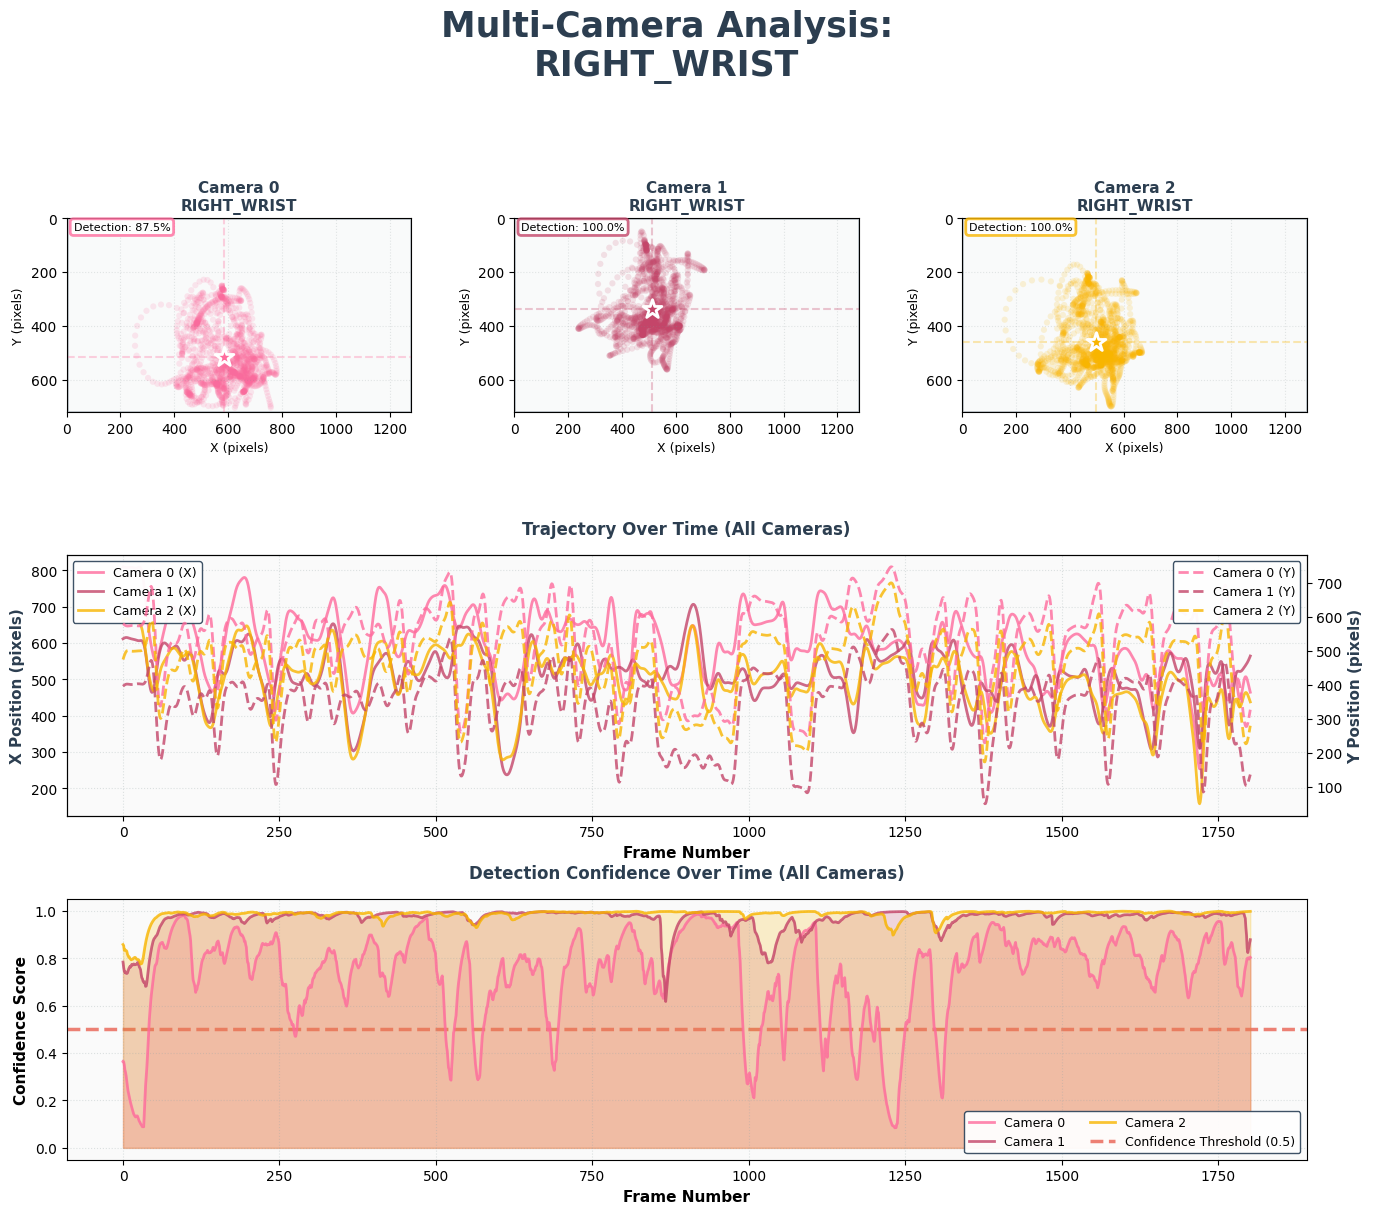


Multi-camera trajectory plot saved to: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/right_wrist_multi_camera_analysis.png

Summary Statistics for RIGHT_WRIST

Camera 0:
  Detection rate: 87.5% (1576/1802 frames)
  Mean confidence: 0.796
  Mean position: (586.1, 515.2) px
  Position std: (91.6, 112.7) px

Camera 1:
  Detection rate: 100.0% (1802/1802 frames)
  Mean confidence: 0.966
  Mean position: (510.9, 338.1) px
  Position std: (76.2, 103.5) px

Camera 2:
  Detection rate: 100.0% (1802/1802 frames)
  Mean confidence: 0.984
  Mean position: (496.1, 460.2) px
  Position std: (82.8, 104.2) px




In [14]:
# ============================================================================
# ENHANCED MULTI-CAMERA KEYPOINT VISUALIZATION
# Starting from already loaded keypoint data
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as patches

# Funky color palette
COLORS = ['#FF6B9D', '#C44569', '#F8B500', '#4ECDC4', '#95E1D3']

# ============================================================================
# Load all camera keypoints
# ============================================================================
data_2d_dir = Path(OUTPUT_DIR) / "data_2d"
keypoint_files = sorted(data_2d_dir.glob("*_keypoints.npy"))

print(f"Found {len(keypoint_files)} camera keypoint files:")
all_camera_keypoints = []
camera_names = []

for i, kp_file in enumerate(keypoint_files):
    keypoints = np.load(kp_file)
    all_camera_keypoints.append(keypoints)
    
    # Extract camera identifier from filename
    # e.g., "camera_0_synchronized_keypoints.npy" -> "Camera 0"
    try:
        cam_num = kp_file.stem.split('_')[1]
        camera_names.append(f'Camera {cam_num}')
    except:
        camera_names.append(f'Camera {i}')
    
    print(f"  {i+1}. {kp_file.name} - Shape: {keypoints.shape}")

print(f"\n✓ Loaded {len(all_camera_keypoints)} camera views")

# ============================================================================
# Choose keypoint to visualize
# ============================================================================
keypoint_idx = 16  # 0 = nose, 15 = left wrist, 16 = right wrist
keypoint_name = processor.MEDIAPIPE_LANDMARK_NAMES[keypoint_idx]

print(f"\nVisualizing: {keypoint_name.upper()} (index {keypoint_idx})")

# ============================================================================
# Setup figure
# ============================================================================
n_cameras = len(all_camera_keypoints)
frame_height, frame_width = 720, 1280  # Adjust if your videos have different resolution

fig = plt.figure(figsize=(16, 13))
gs = fig.add_gridspec(3, n_cameras, height_ratios=[1.2, 1, 1], hspace=0.3, wspace=0.3)

# ============================================================================
# PANEL 1: Representative keypoint locations on each video frame
# ============================================================================
for i, (keypoints, cam_name) in enumerate(zip(all_camera_keypoints, camera_names)):
    ax = fig.add_subplot(gs[0, i])
    
    # Get all positions for this keypoint across time
    positions = keypoints[:, keypoint_idx, :2]  # (n_frames, 2) - X, Y only
    confidences = keypoints[:, keypoint_idx, 2]  # (n_frames,) - confidence
    
    # Filter by confidence threshold
    valid_mask = confidences > 0.5
    valid_positions = positions[valid_mask]
    
    # Create frame representation
    ax.set_xlim(0, frame_width)
    ax.set_ylim(frame_height, 0)  # Inverted Y-axis for image coordinates
    ax.set_aspect('equal')
    
    # Add a subtle background to represent the video frame
    ax.add_patch(patches.Rectangle((0, 0), frame_width, frame_height, 
                                  linewidth=2, edgecolor='#34495E', 
                                  facecolor='#ECF0F1', alpha=0.3))
    
    if len(valid_positions) > 0:
        # Plot all positions with transparency (creates heat map effect)
        ax.scatter(valid_positions[:, 0], valid_positions[:, 1], 
                  c=COLORS[i % len(COLORS)], alpha=0.15, s=20, edgecolors='none')
        
        # Calculate and plot the mean position (representative location)
        mean_x, mean_y = valid_positions.mean(axis=0)
        ax.scatter(mean_x, mean_y, c=COLORS[i % len(COLORS)], 
                  s=200, marker='*', edgecolors='white', linewidths=2,
                  label=f'Mean position', zorder=10)
        
        # Add crosshairs at mean position
        ax.axvline(mean_x, color=COLORS[i % len(COLORS)], 
                  linestyle='--', alpha=0.3, linewidth=1.5)
        ax.axhline(mean_y, color=COLORS[i % len(COLORS)], 
                  linestyle='--', alpha=0.3, linewidth=1.5)
    
    ax.set_title(f'{cam_name}\n{keypoint_name.upper()}', 
                fontsize=11, fontweight='bold', color='#2C3E50')
    ax.set_xlabel('X (pixels)', fontsize=9)
    ax.set_ylabel('Y (pixels)', fontsize=9)
    ax.grid(True, alpha=0.2, linestyle=':', color='#7F8C8D')
    
    # Add detection stats
    detection_rate = (valid_mask.sum() / len(valid_mask)) * 100
    ax.text(0.02, 0.98, f'Detection: {detection_rate:.1f}%', 
           transform=ax.transAxes, fontsize=8, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, 
                    edgecolor=COLORS[i % len(COLORS)], linewidth=2))

# ============================================================================
# PANEL 2: X and Y trajectories over time (all cameras combined)
# ============================================================================
ax_x = fig.add_subplot(gs[1, :])
ax_y = ax_x.twinx()  # Share x-axis for Y trajectory

for i, (keypoints, cam_name) in enumerate(zip(all_camera_keypoints, camera_names)):
    trajectory = keypoints[:, keypoint_idx, :]
    frames = np.arange(len(trajectory))
    
    color = COLORS[i % len(COLORS)]
    
    # Plot X trajectory (solid line)
    ax_x.plot(frames, trajectory[:, 0], linewidth=2, alpha=0.8, 
             color=color, label=f'{cam_name} (X)', linestyle='-')
    
    # Plot Y trajectory (dashed line)
    ax_y.plot(frames, trajectory[:, 1], linewidth=2, alpha=0.8, 
             color=color, label=f'{cam_name} (Y)', linestyle='--')

ax_x.set_xlabel('Frame Number', fontsize=11, fontweight='bold')
ax_x.set_ylabel('X Position (pixels)', fontsize=11, fontweight='bold', color='#2C3E50')
ax_y.set_ylabel('Y Position (pixels)', fontsize=11, fontweight='bold', color='#2C3E50')

ax_x.set_title('Trajectory Over Time (All Cameras)', 
              fontsize=12, fontweight='bold', pad=15, color='#2C3E50')

ax_x.grid(True, alpha=0.3, linestyle=':', color='#95A5A6')
ax_x.legend(loc='upper left', fontsize=9, framealpha=0.95, 
           edgecolor='#34495E', fancybox=True)
ax_y.legend(loc='upper right', fontsize=9, framealpha=0.95, 
           edgecolor='#34495E', fancybox=True)

# Add subtle background
ax_x.set_facecolor('#FAFAFA')

# ============================================================================
# PANEL 3: Confidence over time (all cameras combined)
# ============================================================================
ax_conf = fig.add_subplot(gs[2, :])

for i, (keypoints, cam_name) in enumerate(zip(all_camera_keypoints, camera_names)):
    confidence = keypoints[:, keypoint_idx, 2]
    frames = np.arange(len(confidence))
    
    color = COLORS[i % len(COLORS)]
    
    # Plot confidence with filled area
    ax_conf.plot(frames, confidence, linewidth=2, alpha=0.8, 
                color=color, label=cam_name)
    ax_conf.fill_between(frames, confidence, alpha=0.2, color=color)

# Add threshold line
ax_conf.axhline(y=0.5, color='#E74C3C', linestyle='--', linewidth=2.5, 
               alpha=0.7, label='Confidence Threshold (0.5)', zorder=0)

ax_conf.set_xlabel('Frame Number', fontsize=11, fontweight='bold')
ax_conf.set_ylabel('Confidence Score', fontsize=11, fontweight='bold')
ax_conf.set_title('Detection Confidence Over Time (All Cameras)', 
                 fontsize=12, fontweight='bold', pad=15, color='#2C3E50')

ax_conf.set_ylim(-0.05, 1.05)
ax_conf.grid(True, alpha=0.3, linestyle=':', color='#95A5A6')
ax_conf.legend(loc='lower right', fontsize=9, framealpha=0.95, 
              edgecolor='#34495E', fancybox=True, ncol=2)

# Add subtle background
ax_conf.set_facecolor('#FAFAFA')

# ============================================================================
# Overall styling
# ============================================================================
fig.suptitle(f'Multi-Camera Analysis:\n{keypoint_name.upper()}', 
            fontsize=25, fontweight='bold', y=0.995, color='#2C3E50')

# Save the figure
output_path = Path(OUTPUT_DIR) / f'{keypoint_name}_multi_camera_analysis.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nMulti-camera trajectory plot saved to: {output_path}")

# ============================================================================
# Print summary statistics
# ============================================================================
print(f"\n{'='*70}")
print(f"Summary Statistics for {keypoint_name.upper()}")
print(f"{'='*70}")

for i, (keypoints, cam_name) in enumerate(zip(all_camera_keypoints, camera_names)):
    confidence = keypoints[:, keypoint_idx, 2]
    valid_frames = (confidence > 0.5).sum()
    total_frames = len(confidence)
    detection_rate = (valid_frames / total_frames) * 100
    mean_confidence = confidence[confidence > 0.5].mean() if valid_frames > 0 else 0
    
    # Get position stats for valid detections
    positions = keypoints[:, keypoint_idx, :2]
    valid_positions = positions[confidence > 0.5]
    
    if len(valid_positions) > 0:
        mean_x, mean_y = valid_positions.mean(axis=0)
        std_x, std_y = valid_positions.std(axis=0)
    else:
        mean_x = mean_y = std_x = std_y = 0
    
    print(f"\n{cam_name}:")
    print(f"  Detection rate: {detection_rate:.1f}% ({valid_frames}/{total_frames} frames)")
    print(f"  Mean confidence: {mean_confidence:.3f}")
    print(f"  Mean position: ({mean_x:.1f}, {mean_y:.1f}) px")
    print(f"  Position std: ({std_x:.1f}, {std_y:.1f}) px")

print(f"\n{'='*70}\n")

## Summary of outputs

In [15]:
print("\n" + "="*70)
print("OUTPUT FILES CREATED")
print("="*70)

labeled_videos_dir = Path(OUTPUT_DIR) / "labeled_videos"
data_2d_dir = Path(OUTPUT_DIR) / "data_2d"

print(f"\nLabeled Videos (with skeleton overlay):")
for video in labeled_videos_dir.glob("*.mp4"):
    print(f"  {video}")

print(f"\n2D Keypoint Data:")
for npy_file in data_2d_dir.glob("*_keypoints.npy"):
    print(f"  {npy_file}")

print(f"\nSummary Report:")
summary_file = Path(OUTPUT_DIR) / "pose_estimation_summary.txt"
if summary_file.exists():
    print(f"  {summary_file}")

print("\n2D Pose Estimation Complete!")



OUTPUT FILES CREATED

Labeled Videos (with skeleton overlay):
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/labeled_videos/camera_2_synchronized_labeled.mp4
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/labeled_videos/camera_1_synchronized_labeled.mp4
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/labeled_videos/camera_0_synchronized_labeled.mp4

2D Keypoint Data:
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d/camera_2_synchronized_keypoints.npy
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d/camera_0_synchronized_keypoints.npy
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d/camera_1_synchronized_keypoints.npy

Summary Report:
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/pose_estimation_summary.txt

2D Pose Estimation Complet

In [ ]:
# ============================================================================
# STEP 6: Save the 3D data
# ============================================================================
# Save in multiple formats for easy loading later

print("\n" + "="*70)
print("Saving 3D data...")
print("="*70)

# Save the 3D points
projector.save_3d_data(
    points_3d,
    output_path=str(Path(OUTPUT_3D_DIR) / "pose_3d"),
    metadata={
        'processing_date': '2026-02-06',
        'recording_session': '2026-02-06_15-06-02',
        'min_cameras': 2,
        'confidence_threshold': 0.3
    }
)

# Save the metrics
projector.save_metrics(
    metrics,
    output_path=str(Path(OUTPUT_3D_DIR) / "projection_metrics.txt")
)

print("✓ 3D data saved!")

2026-02-06 15:56:45,694 - INFO - Saved 3D points to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.npy
2026-02-06 15:56:45,697 - INFO - Saved metadata to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.json
2026-02-06 15:56:45,698 - INFO - Saved metrics to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/projection_metrics.txt



Saving 3D data...
✓ 3D data saved!
